In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
import jax.numpy as jnp
import jax
import json
import os

from nrt.helpers import encode
from nrt.data import TrajectoryGenerator


In [11]:
filepath = '../data/260128/fixed_Xi_chi_multiplication_sweep_knorm_varied_seed/run002'
counter = 1
save_fig = 0
plot_scale = 1

if counter == '':
    adding_string = ''
else:
    adding_string = '_'

%cd "$filepath"

# Load parameters
with open('parameters.json', 'r') as json_file:
    parameters = json.load(json_file)

# Load g0 (activity at origin) instead of W
with open('g0' + adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    g0 = pickle.load(pickle_file)

# Load frequencies
with open('om'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    om = pickle.load(pickle_file)

# Load transformation matrix S
with open('S'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    S = pickle.load(pickle_file)

# Load losses
with open('min_L'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    min_L = pickle.load(pickle_file)

with open('L'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    L = pickle.load(pickle_file)

# Load initial values
with open('g0_init'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    g0_init = pickle.load(pickle_file)

with open('S_init'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
    S_init = pickle.load(pickle_file)

# Load final values
try:
    with open('g0_final'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        g0_final = pickle.load(pickle_file)
except:
    g0_final = g0

try:
    with open('S_final'+ adding_string + f'{counter}.pkl', 'rb') as pickle_file:
        S_final = pickle.load(pickle_file)
except:
    S_final = S

# Use final values if min loss is poor
# if min_L[0] < 1:
#     g0 = g0_final
#     S = S_final

# Compute D from g0 shape
D = g0.shape[0]
M = int((D - 1) / 2)

print(f"Loaded optimization results:")
print(f"  D = {D}, M = {M}")
print(f"  g0 shape: {g0.shape}")
print(f"  S shape: {S.shape}")
print(f"  om shape: {om.shape}")
print(f"  Min loss: {min_L[1]:.5f}")

[Errno 2] No such file or directory: '../data/260128/fixed_Xi_chi_multiplication_sweep_knorm_varied_seed/run002'
/home/julian/Projects/MasterThesis/ICLR_Actionable_Reps/data/260128/fixed_Xi_chi_multiplication_sweep_knorm_varied_seed/run002
Loaded optimization results:
  D = 65, M = 32
  g0 shape: (65,)
  S shape: (65, 65)
  om shape: (32, 2)
  Min loss: 0.24572


## Encode 

In [12]:
generator = TrajectoryGenerator()

data = jnp.asarray(generator.generate_trajectory(2, 2, 1, 10000))
representations = np.asarray(encode(g0, om, S, data))

B, L, D = representations.shape
representations = representations.reshape(B * L, D)

## PCA

Variance explained by each PC:
PC1: 20.78%
PC2: 15.91%
PC3: 10.22%
PC4: 8.98%
PC5: 8.24%
PC6: 6.09%
Total variance explained: 70.21%


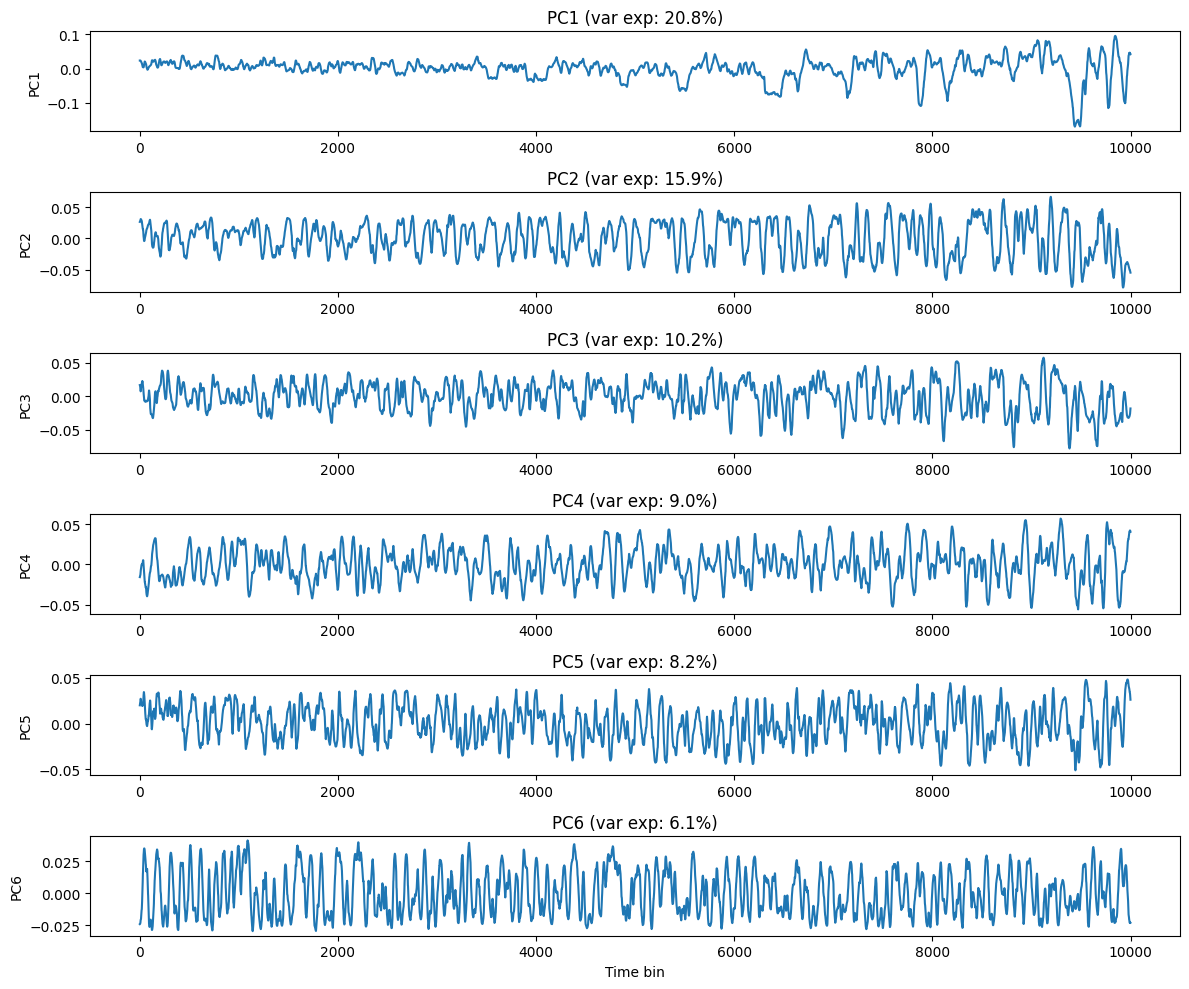

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=6)
pcs = pca.fit_transform(representations)

print("Variance explained by each PC:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var*100:.2f}%")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Visualize the principal components over time
fig, axes = plt.subplots(6, 1, figsize=(12, 10))
for i in range(6):
    axes[i].plot(pcs[:, i])
    axes[i].set_ylabel(f'PC{i+1}')
    axes[i].set_title(f'PC{i+1} (var exp: {pca.explained_variance_ratio_[i]*100:.1f}%)')
axes[-1].set_xlabel('Time bin')
plt.tight_layout()
plt.show()

/home/julian/Projects/MasterThesis/ICLR_Actionable_Reps/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


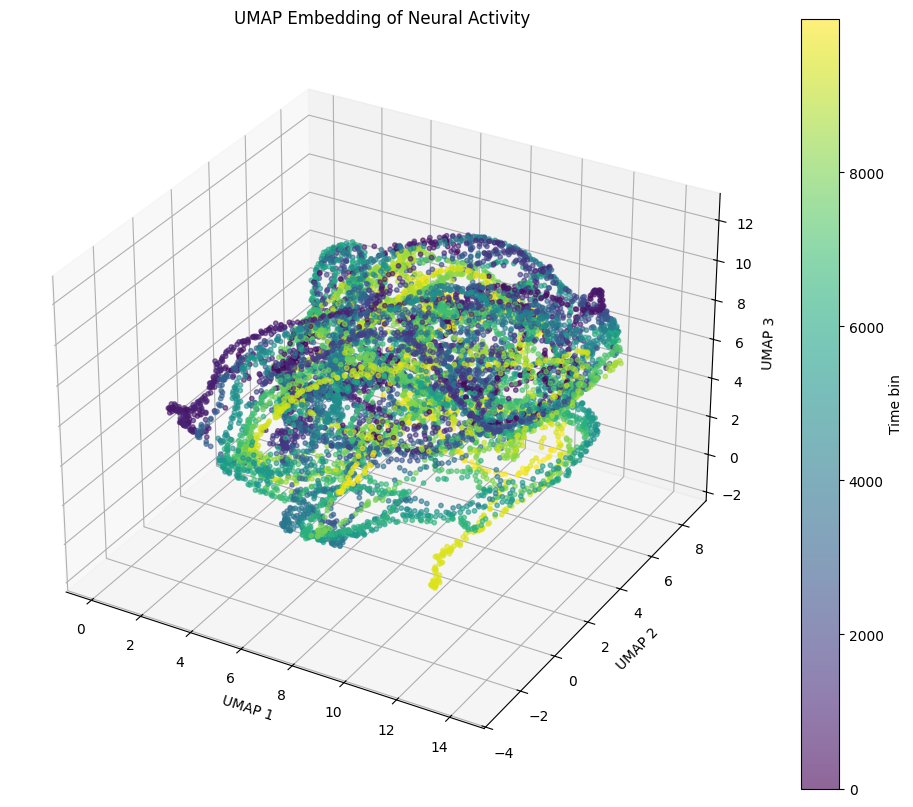

In [14]:
import umap
from mpl_toolkits.mplot3d import Axes3D

reducer = umap.UMAP(
    n_components=3,
    metric='cosine',
    n_neighbors=5000,
    min_dist=0.8,
    init='spectral',
    random_state=42
)

embedding = reducer.fit_transform(pcs)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Color by time to see temporal progression
time_colors = np.arange(len(embedding))
scatter = ax.scatter(
    embedding[:, 0], 
    embedding[:, 1], 
    embedding[:, 2],
    c=time_colors,
    cmap='viridis',
    s=10,
    alpha=0.6
)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
ax.set_title('UMAP Embedding of Neural Activity')
plt.colorbar(scatter, label='Time bin', ax=ax)
plt.show()